In [2]:
class Pt:
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def __sub__(self, p):
        return Pt(self.x - p.x, self.y - p.y)

class Circle(Pt):
    def __init__(self, x, y, r):
        super().__init__(x, y)
        self.r = r

class Line:
    def __init__(self, a, b, c):
        self.a = a
        self.b = b
        self.c = c

EPS = 1E-9

def sqr(a):
    return a * a

def tangents(c, r1, r2):
    ans = []
    r = r2 - r1
    z = sqr(c.x) + sqr(c.y)
    d = z - sqr(r)
    if d < -EPS:
        return ans
    d = abs(d) ** 0.5
    l = Line((c.x * r + c.y * d) / z, (c.y * r - c.x * d) / z, r1)
    ans.append(l)
    return ans

def all_tangents(a, b):
    ans = []
    for i in [-1, 1]:
        for j in [-1, 1]:
            ans.extend(tangents(b - a, a.r * i, b.r * j))
    for l in ans:
        l.c -= l.a * a.x + l.b * a.y
    return ans

UCS: 4 MPa
UTS: 0.5 MPa
y = 0.8944271909999159 x + 0.894427190999916
cohesion: 0.894427190999916 MPa
fric. angle (deg): 41.810314895778596


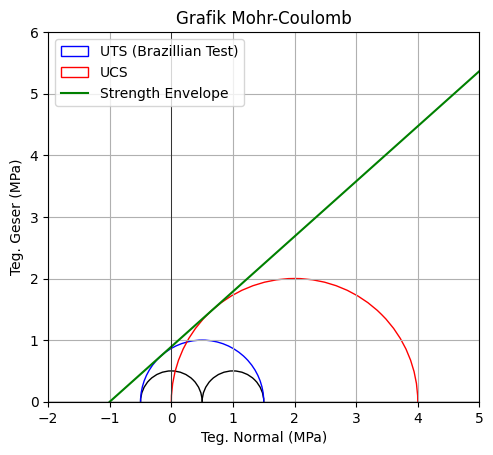

In [3]:
import math
import matplotlib.pyplot as plt
import numpy as np

# in MPa
ucs = 4
uts = 0.5

print("UCS:", ucs, "MPa")
print("UTS:", uts, "MPa")

small_uts = (uts / 1)
x_uts = 0 + small_uts
r_uts = uts + small_uts

# uts (support circle)
circ_s1 = Circle(0,0,uts)
circ_s2 = Circle(uts + small_uts, 0, small_uts) # smaller one

circ1 = Circle(x_uts,0,r_uts) # uts in red
circ2 = Circle(ucs/2,0,ucs/2) # ucs in blue

for l in all_tangents(circ1, circ2):
    # ax + by + c = 0
    # y = (-ax - c) b
    if (-l.c/l.b) < 0:
        continue
    # print("y = ax + b")
    gradien = (-l.a/l.b)
    cohesi = (-l.c/l.b)
    print("y =", gradien, "x +", cohesi)

    print("cohesion:", cohesi, "MPa")
    print("fric. angle (deg):", math.degrees(math.atan(gradien)))

    # Create a figure and axis
    fig, ax = plt.subplots()
    ax.set_aspect(1)

    # Circle 1: Center (0, 0), Radius 3
    circle1 = plt.Circle((circ_s1.x, circ_s1.y), circ_s1.r, color='black', fill=False)
    ax.add_artist(circle1)

    # Circle 1: Center (0, 0), Radius 3
    circle2 = plt.Circle((circ_s2.x, circ_s2.y), circ_s2.r, color='black', fill=False)
    ax.add_artist(circle2)

    # Circle 1: Center (0, 0), Radius 3
    circle3 = plt.Circle((circ1.x, circ1.y), circ1.r, color='blue', fill=False, label='UTS (Brazillian Test)')
    ax.add_artist(circle3)

    # Circle 2: Center (5, 0), Radius 5
    circle4 = plt.Circle((circ2.x, circ2.y), circ2.r, color='red', fill=False, label='UCS')
    ax.add_artist(circle4)

    # Line: y = 0.639009650422694x + 2.7386127875258306
    x_vals = np.linspace(-2*uts, 1.5*ucs, 100)
    y_vals = gradien * x_vals + cohesi
    plt.plot(x_vals, y_vals, color='green', label='Strength Envelope')

    # Set axis limits, make box the same
    plt.xlim(-round(uts*2) - 1, round(ucs*1) + 1)
    plt.ylim(0, ucs+2)

    # Add labels and legend
    plt.xlabel('Teg. Normal (MPa)')
    plt.ylabel('Teg. Geser (MPa)')
    plt.title('Grafik Mohr-Coulomb')
    plt.legend()

    # Show the plot
    plt.grid(True)
    plt.axhline(0, color='black', linewidth=1)
    plt.axvline(0, color='black', linewidth=0.5)
    plt.show()



In [4]:
# AUTOMATE MAX MIN MEAN STD

# in MPa
def get_c_and_phi(ucs, uts):
    small_uts = (uts / 1)
    x_uts = 0 + small_uts
    r_uts = uts + small_uts

    # uts (support circle)
    circ_s1 = Circle(0,0,uts)
    circ_s2 = Circle(uts + small_uts, 0, small_uts) # smaller one

    circ1 = Circle(x_uts,0,r_uts) # uts in red
    circ2 = Circle(ucs/2,0,ucs/2) # ucs in blue

    for l in all_tangents(circ1, circ2):
        # ax + by + c = 0
        # y = (-ax - c) b
        if (-l.c/l.b) < 0:
            continue
        # print("y = ax + b")
        gradien = (-l.a/l.b)
        cohesi = (-l.c/l.b)

        if math.degrees(math.atan(gradien)) < 0:
            continue

        return [cohesi, math.degrees(math.atan(gradien))]

ucs_data = [4, 5.72, 7.02]
uts_data = [0.481, 0.5, 0.401]

cohesi_data = list()
phi_data = list()

for ucs in ucs_data:
    for uts in uts_data:
        res = get_c_and_phi(ucs,uts)
        if res == None:
            print("TOO SMALL", ucs, uts)
        else:
            cohesi_data.append(res[0])
            phi_data.append(res[1])

print("")
print("COHESI:", cohesi_data)
print("REL. MIN:", np.mean(cohesi_data) - np.min(cohesi_data))
print("REL. MAX:", np.max(cohesi_data) - np.mean(cohesi_data))
print("MEAN:", np.mean(cohesi_data))
print("STD_DEV:", np.std(cohesi_data))
print("")
print("FRIC ANGLE:", phi_data)
print("REL. MIN:", np.mean(phi_data) - np.min(phi_data))
print("REL. MAX:", np.max(phi_data) - np.mean(phi_data))
print("MEAN:", np.mean(phi_data))
print("STD_DEV:", np.std(phi_data))


      


COHESI: [0.8674354561750653, 0.894427190999916, 0.7572790613038962, 0.9591111640075991, 0.9844525988747652, 0.8521443604632339, 1.0308116837098455, 1.0563858608276246, 0.9215730603817877]
REL. MIN: 0.16756765388985184
REL. MAX: 0.1315391456338766
MEAN: 0.9248467151937481
STD_DEV: 0.08872848919425026

FRIC ANGLE: [43.10553487396914, 41.810314895778596, 48.522706587261126, 52.921878584247516, 52.01161955354002, 56.816878314148646, 57.26723634047763, 56.500126763139924, 60.577343006971766]
REL. MIN: 10.36008942861411
REL. MAX: 8.40693868257906
MEAN: 52.170404324392706
STD_DEV: 6.149882271837588


y = 0.9536612065978659 x + 2.9865165745396425
cohesion: 2.9865165745396425 MPa
fric. angle (deg): 43.641259009217755


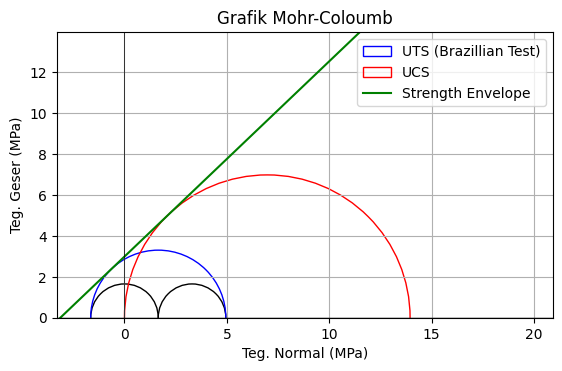

In [4]:
# in MPa
ucs = 13.95
uts = 1.65

small_uts = (uts)
x_uts = 0 + small_uts
r_uts = uts + small_uts

# uts (support circle)
circ_s1 = Circle(0,0,uts)
circ_s2 = Circle(uts + small_uts, 0, small_uts) # smaller one

circ1 = Circle(x_uts,0,r_uts) # uts in red
circ2 = Circle(ucs/2,0,ucs/2) # ucs in blue

for l in all_tangents(circ1, circ2):
    # ax + by + c = 0
    # y = (-ax - c) b
    if (-l.c/l.b) < 0:
        continue
    # print("y = ax + b")
    gradien = (-l.a/l.b)
    cohesi = (-l.c/l.b)
    print("y =", gradien, "x +", cohesi)

    print("cohesion:", cohesi, "MPa")
    print("fric. angle (deg):", math.degrees(math.atan(gradien)))

    # Create a figure and axis
    fig, ax = plt.subplots()
    ax.set_aspect(1)

    # Circle 1: Center (0, 0), Radius 3
    circle1 = plt.Circle((circ_s1.x, circ_s1.y), circ_s1.r, color='black', fill=False)
    ax.add_artist(circle1)

    # Circle 1: Center (0, 0), Radius 3
    circle2 = plt.Circle((circ_s2.x, circ_s2.y), circ_s2.r, color='black', fill=False)
    ax.add_artist(circle2)

    # Circle 1: Center (0, 0), Radius 3
    circle3 = plt.Circle((circ1.x, circ1.y), circ1.r, color='blue', fill=False, label='UTS (Brazillian Test)')
    ax.add_artist(circle3)

    # Circle 2: Center (5, 0), Radius 5
    circle4 = plt.Circle((circ2.x, circ2.y), circ2.r, color='red', fill=False, label='UCS')
    ax.add_artist(circle4)

    # Line: y = 0.639009650422694x + 2.7386127875258306
    x_vals = np.linspace(-2*uts, 1.2*ucs, 100)
    y_vals = gradien * x_vals + cohesi
    plt.plot(x_vals, y_vals, color='green', label='Strength Envelope')

    # Set axis limits
    plt.xlim(-uts*2, ucs*1.5)
    plt.ylim(0, ucs)

    # Add labels and legend
    plt.xlabel('Teg. Normal (MPa)')
    plt.ylabel('Teg. Geser (MPa)')
    plt.title('Grafik Mohr-Coulomb')
    plt.legend()

    # Show the plot
    plt.grid(True)
    plt.axhline(0, color='black', linewidth=1)
    plt.axvline(0, color='black', linewidth=0.5)
    plt.show()